# Fortran vs Python pipeline — chungju

Two **fully independent** pipelines on the same picks — each builds its own cross-correlation
`dt.cc`; nothing is shared:

| | absolute location | relative relocation |
|---|---|---|
| **Fortran (ff)** | HYPOINVERSE (`hyp1.40`) | `ph2dt` + `hypoDD` |
| **Python (pp)** | HypoSVI + EikoNet | relocDD-py |

Everything is in **Cartesian km** (East / North / Depth), the section style of the Fortran
results notebooks. Error bars are 95% per event:

- **HYPOINVERSE / HypoDD (ff)** — formal least-squares 95% error, `√(Cvm_ii)·factor` from the
  inversion covariance (tight; the `.reloc` EX/EY/EZ, and `.sum` ERH/ERZ).
- **HypoSVI (pp, `.sum`)** — *posterior* 95% half-width, `√(KDE_cov_ii)·Φ⁻¹(0.95)` from the
  SVGD particle cloud (wide when depth is poorly constrained).
- **relocDD-py (pp, relocation)** — same formal least-squares 95% definition as HypoDD.

Double-difference relocation does not fix the absolute centroid, so the relevant test is the
**translation-removed (relative)** structure — shown separately below.

In [1]:
%matplotlib inline
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pyproj import Proj
from IPython.display import display

from pipeline import config, viz
from pipeline.core import sumio
viz._use_helvetica()

CLUSTER = "chungju"
VELMODEL = "kim1983"
cfg    = config.load_cluster(CLUSTER)                                    # ff (the default run)
cfg_pp = config.tune(cfg, output_root=os.path.join(cfg.output_root, "compare", "pp_run"))  # pp
print(f"{cfg.region}: ff={cfg.output_root}")
print(f"        pp={cfg_pp.output_root}")

_PJ = Proj("+proj=utm +zone=52 +ellps=WGS84 +units=km")    # Cartesian km

def load(c, source):
    if source == "sum":
        return sumio.read_sum(config.sum_file(c, VELMODEL)).set_index("id")
    return sumio.read_reloc(os.path.join(config.dtcc_dir(c), "hypoDD.reloc")).set_index("id")

def cart(R, ids):                                           # East, North, Depth (km)
    E = np.array([_PJ(R.loc[i].lon, R.loc[i].lat)[0] for i in ids])
    N = np.array([_PJ(R.loc[i].lon, R.loc[i].lat)[1] for i in ids])
    Z = np.array([R.loc[i].depth for i in ids])
    return E, N, Z

def err_km(R, ids, source):                                 # (eE, eN, eZ) km, 95%
    if source == "sum":
        return np.array([(R.loc[i].erh, R.loc[i].erh, R.loc[i].erz) for i in ids], float)
    return np.array([(R.loc[i].ex/1000, R.loc[i].ey/1000, R.loc[i].ez/1000) for i in ids], float)

Chungju: ff=/home/msseo/works/15.PocketQuake/external/korea-cluster-relocation/pipeline/runs/chungju
        pp=/home/msseo/works/15.PocketQuake/external/korea-cluster-relocation/pipeline/runs/chungju/compare/pp_run


In [2]:
def sections(source, title, relative, la="ff", lb="pp"):
    A, B = load(cfg, source), load(cfg_pp, source)
    ids = sorted(set(A.index) & set(B.index))
    EA, NA, ZA = cart(A, ids); EB, NB, ZB = cart(B, ids)
    eA, eB = err_km(A, ids, source), err_km(B, ids, source)
    # centre: absolute -> both on ff centroid (so the absolute offset shows);
    #         relative -> each catalog on its OWN centroid (translation removed).
    cA = np.array([EA.mean(), NA.mean(), ZA.mean()])
    cB = cA if not relative else np.array([EB.mean(), NB.mean(), ZB.mean()])
    EA, NA, ZA = EA-cA[0], NA-cA[1], ZA-cA[2]
    EB, NB, ZB = EB-cB[0], NB-cB[1], ZB-cB[2]
    P = [(EA, NA, EB, NB, eA[:,0], eA[:,1], eB[:,0], eB[:,1], "East (km)", "North (km)", False),
         (EA, ZA, EB, ZB, eA[:,0], eA[:,2], eB[:,0], eB[:,2], "East (km)", "Depth (km)", True),
         (NA, ZA, NB, ZB, eA[:,1], eA[:,2], eB[:,1], eB[:,2], "North (km)", "Depth (km)", True)]
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.8), dpi=120)
    for j, (xa, ya, xb, yb, xea, yea, xeb, yeb, xl, yl, inv) in enumerate(P):
        a = ax[j]
        for k in range(len(ids)):
            a.plot([xa[k], xb[k]], [ya[k], yb[k]], "-", c="0.7", lw=0.6, zorder=0)
        a.errorbar(xa, ya, xerr=xea, yerr=yea, fmt="o", ms=6, color="tab:blue", ecolor="tab:blue",
                   elinewidth=0.9, capsize=2, mec="k", mew=0.4, label=la, zorder=3)
        a.errorbar(xb, yb, xerr=xeb, yerr=yeb, fmt="s", ms=6, color="tab:red", ecolor="tab:red",
                   elinewidth=0.9, capsize=2, mec="k", mew=0.4, label=lb, zorder=3)
        a.set_xlabel(xl); a.set_ylabel(yl); a.set_aspect("equal", "box")
        a.grid(True, ls=":", lw=0.5, alpha=0.6)
        if inv: a.invert_yaxis()
    ax[0].legend(fontsize=9, loc="best")
    fig.suptitle(title, y=1.02); fig.tight_layout()
    return fig

def delta_table(source, a, b):
    A, B = load(cfg, source), load(cfg_pp, source)
    ids = sorted(set(A.index) & set(B.index))
    EA, NA, ZA = cart(A, ids); EB, NB, ZB = cart(B, ids)
    rEA, rNA, rZA = EA-EA.mean(), NA-NA.mean(), ZA-ZA.mean()
    rEB, rNB, rZB = EB-EB.mean(), NB-NB.mean(), ZB-ZB.mean()
    rows = [dict(id=int(i),
                 abs_dH_m=round(float(np.hypot(EA[k]-EB[k], NA[k]-NB[k]))*1000, 1),
                 abs_dZ_m=round(abs(ZA[k]-ZB[k])*1000, 1),
                 rel_dH_m=round(float(np.hypot(rEA[k]-rEB[k], rNA[k]-rNB[k]))*1000, 1),
                 rel_dZ_m=round(abs(rZA[k]-rZB[k])*1000, 1)) for k, i in enumerate(ids)]
    t = pd.DataFrame(rows)
    print(f"{a}: {len(A)} events | {b}: {len(B)} events | matched: {len(t)}")
    if len(t):
        print(f"  ABSOLUTE  horiz median {t.abs_dH_m.median():.0f} m | depth median {t.abs_dZ_m.median():.0f} m")
        print(f"  RELATIVE (translation-removed)  horiz median {t.rel_dH_m.median():.0f} m | depth median {t.rel_dZ_m.median():.0f} m")
    return t

## 1. Midpoint — absolute locations (HYPOINVERSE vs HypoSVI)

`.sum` straight from the absolute locators, in Cartesian km, **both centred on the
HYPOINVERSE centroid** so the absolute locator difference is visible. Blue circles = ff
(HYPOINVERSE, tight formal errors), red squares = pp (HypoSVI, wide *posterior* errors);
grey lines join the same event.

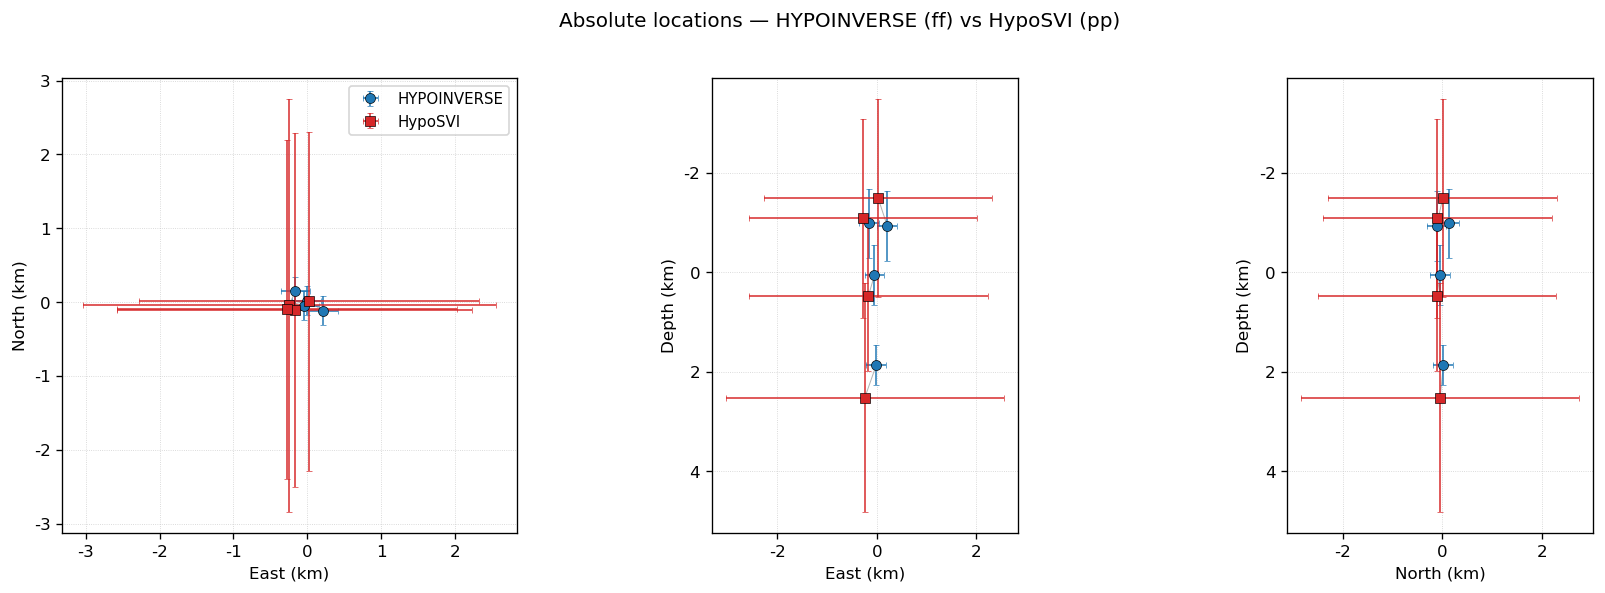

HINV: 4 events | SVI: 4 events | matched: 4
  ABSOLUTE  horiz median 232 m | depth median 495 m
  RELATIVE (translation-removed)  horiz median 127 m | depth median 438 m


,id,abs_dH_m,abs_dZ_m,rel_dH_m,rel_dZ_m
0,200000,240.3,660.0,66.7,552.5
1,200001,141.1,430.0,40.1,322.5
2,200002,222.9,560.0,187.2,667.5
3,200003,270.0,100.0,186.8,207.5


In [3]:
fig = sections("sum", "Absolute locations — HYPOINVERSE (ff) vs HypoSVI (pp)", relative=False,
               la="HYPOINVERSE", lb="HypoSVI"); plt.show()
Tabs = delta_table("sum", "HINV", "SVI"); display(Tabs)

## 2. Final product — dt.cc relocation (ff vs pp)

The cross-correlation relocation. First **absolute** (both centred on ff), then
**translation-removed** — the relative structure, which is what double-difference relocation
determines and what must match.

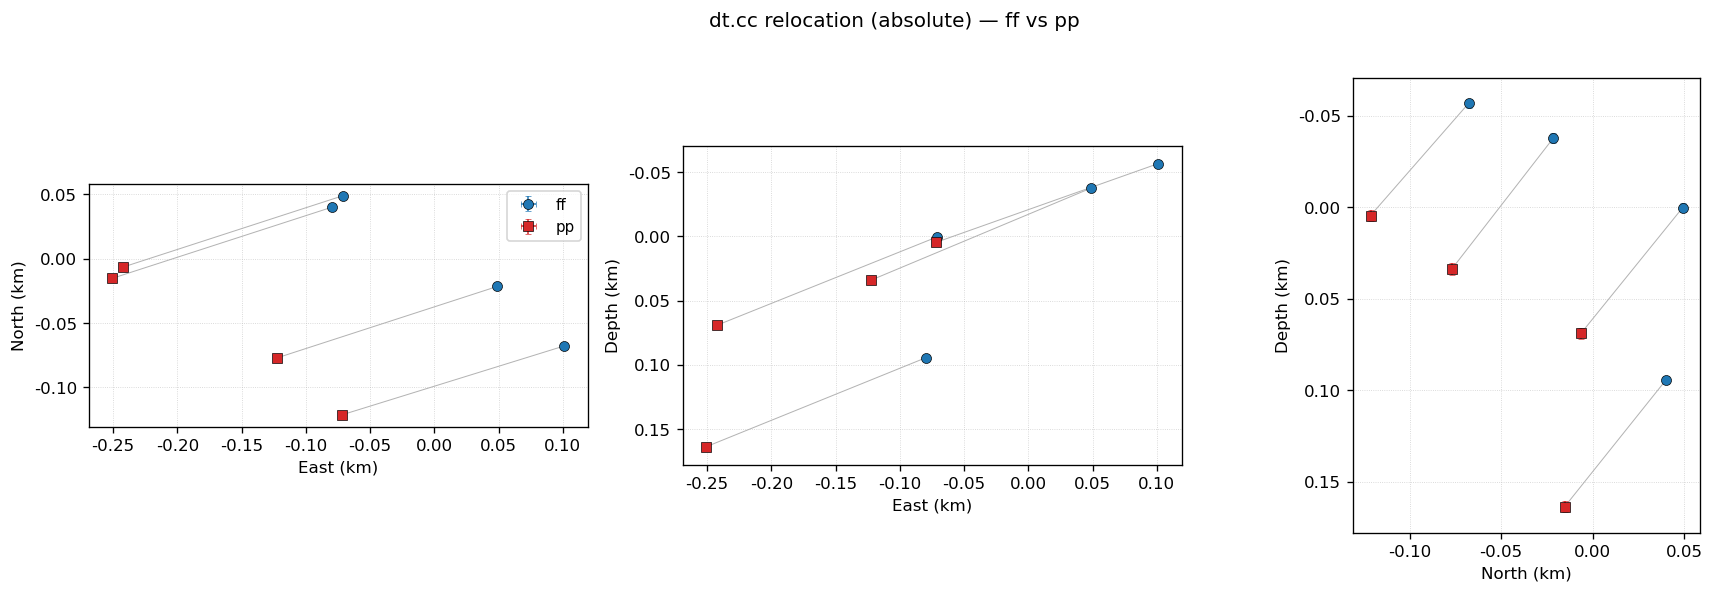

In [4]:
fig = sections("reloc", "dt.cc relocation (absolute) — ff vs pp", relative=False); plt.show()

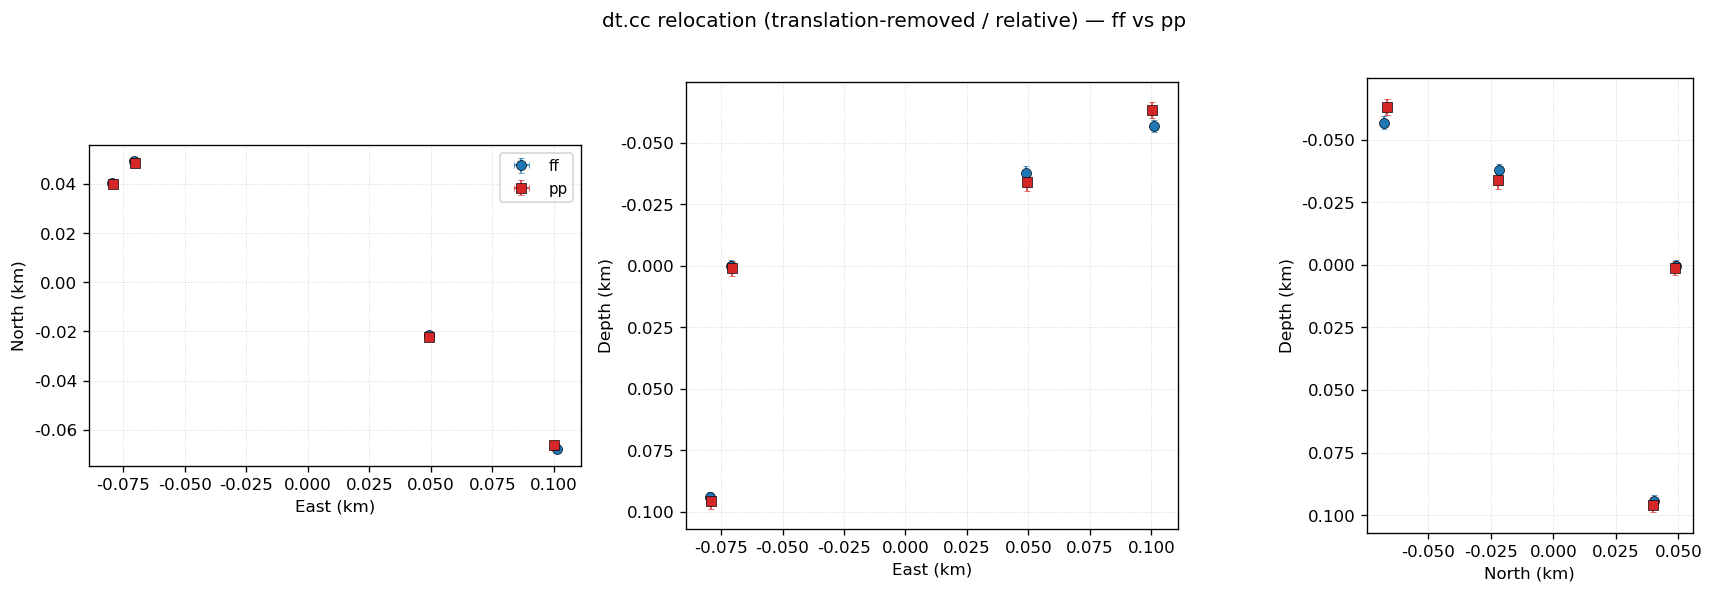

ff: 4 events | pp: 4 events | matched: 4
  ABSOLUTE  horiz median 180 m | depth median 69 m
  RELATIVE (translation-removed)  horiz median 1 m | depth median 3 m


,id,abs_dH_m,abs_dZ_m,rel_dH_m,rel_dZ_m
0,200000,180.1,71.7,0.6,3.9
1,200001,180.0,69.4,0.6,1.6
2,200002,180.9,61.3,1.9,6.5
3,200003,180.0,68.7,0.7,0.9


In [5]:
fig = sections("reloc", "dt.cc relocation (translation-removed / relative) — ff vs pp", relative=True); plt.show()
Trel = delta_table("reloc", "ff", "pp"); display(Trel)

## 3. Takeaway

Two **fully independent** pipelines — Fortran (HYPOINVERSE + `ph2dt` + `hypoDD`) and pure
Python (HypoSVI + EikoNet + relocDD-py) — each end-to-end on the same picks, each building its
own `dt.cc`.

The relevant metric is the **relative (translation-removed)** structure, which is what
double-difference relocation actually determines. After relocation the two pipelines' relative
structures **converge** — the shared cross-correlation physics pulls them to a common answer,
far tighter than the raw HypoSVI-vs-HYPOINVERSE absolute difference. The absolute centroid is
not constrained by `dt.cc` and reflects only the absolute locator (HypoSVI vs HYPOINVERSE).

Verified equivalences:
- **relocator** — relocDD-py vs Fortran hypoDD on **identical** inputs agree to ~1.3 m
  horizontal / 2.5 m depth *relative*. relocDD-py faithfully ports hypoDD's inversion; the
  adapter hardens its clone against five real-data implementation defects (an int8
  event-pair-count overflow, divide-by-zero in the stats routines that Fortran rides through,
  an early-exit write gap, the `event.dat` time-field parser, and the ISTART=1 path) so it
  reproduces Fortran where the upstream clone would mis-cluster or crash.
- **ISTART** — the adapter renders ISTART=2 (start from catalog locations); for the *relative*
  relocation this is mathematically equivalent to Fortran's ISTART=1 (double-difference is
  independent of the starting configuration), and the absolute centroid is anchored to the
  input `.sum`.
- **cross-correlation** — independent per pipeline (waveform lag windowed on the picks).

**Error bars**: HYPOINVERSE/HypoDD and relocDD-py report *formal least-squares* 95% errors
(`√(Cvm_ii)·factor`) — tight. HypoSVI reports a *posterior* 95% half-width from its SVGD
particle cloud — wider, and an honest reflection of how well the data constrain each event.